# Notebook 5 — First Hubble diagram with real Type Ia supernova data

In this notebook, we move from simulated data to real Type Ia supernova data.

The goal is not to reproduce the full Pantheon+SH0ES analysis. Instead, we want to learn how to load real supernova data, inspect the columns, make a Hubble diagram, and understand the role of calibration.

> **Scope of this notebook:**
> This notebook is deliberately pedagogical. Part A uses quantities provided by
> the Pantheon+SH0ES release for visualization. Part B constructs a simplified
> distance-ladder model using plotting-only diagonal uncertainties and the
> approximation $d_L \simeq cz/H_0$. Its numerical result must not be interpreted
> as a cosmological measurement. Notebook 6 replaces these approximations with
> the full published covariance matrix and a more accurate luminosity-distance model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

import emcee
import corner

c_km_s = 299792.458  # speed of light in km/s

## 1. Loading real supernova data

In the previous notebook, the data were simulated. Here, we work with a real table of Type Ia supernova measurements.

The data are taken from the public Pantheon+SH0ES release. For reproducibility,
the URL below is pinned to a fixed commit rather than to the moving `main` branch.

The table contains light-curve measurements. Several rows can therefore correspond
to different observations of the same physical supernova.

https://github.com/PantheonPlusSH0ES/DataRelease

The first goal is simply to load the table, inspect its columns, and identify which quantities are useful for a first Hubble diagram.

In [2]:
data_commit = "7fc680548d1ea9fe6ee983a89d8b5635bb5784a8"

data_url = (
    "https://raw.githubusercontent.com/PantheonPlusSH0ES/"
    f"DataRelease/{data_commit}/"
    "Pantheon%2B_Data/4_DISTANCES_AND_COVAR/"
    "Pantheon%2BSH0ES.dat"
)

df = pd.read_csv(data_url, sep=r"\s+")
df.head()

,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.8859,0.864470,0.0991,1.4960,0.0381,0.005,1.0,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.3064,0.812220,0.0971,1.4960,-0.0252,0.003,1.0,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.5000,0.000358,0.0399,0.7134,0.0545,0.019,1.0,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.1220,0.000193,0.0931,0.7134,0.0622,0.028,1.0,0.040
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,0.0522,146,109.8390,0.988740,0.0567,0.6110,0.0650,0.009,1.0,0.006


In [3]:
print(df.shape)
print(df.columns)

(1701, 47)
Index(['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL',
       'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES',
       'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF',
       'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c',
       'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC',
       'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS',
       'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB',
       'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b',
       'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD'],
      dtype='str')


## 2. First inspection of the dataset

Before doing any fit, we inspect the dataset.

Important questions:

1. How many rows are in the table?
2. What are the column names?
3. Which column contains redshift?
4. Which column contains distance modulus or corrected magnitude?
5. Are there calibrator supernovae?
6. Are there uncertainty columns?
7. Are there missing values?

At this stage, the goal is not to model the data, but to understand what the table contains.

The full Pantheon+SH0ES table contains many columns. In this notebook, we do not keep all of them.

Instead, we build two smaller working tables with clear roles.

Part A uses the provided distance modulus to make a descriptive Hubble diagram.

Part B uses corrected apparent magnitudes and Cepheid distances to build a simplified distance-ladder fit.

In [4]:
print(df.describe())

          IDSURVEY          zHD       zHDERR         zCMB      zCMBERR  \
count  1701.000000  1701.000000  1701.000000  1701.000000  1701.000000   
mean     37.017637     0.221229     0.001840     0.221090     0.001155   
std      45.916840     0.249271     0.002593     0.249337     0.002774   
min       1.000000     0.001220     0.000840     0.001220     0.000000   
25%       4.000000     0.027730     0.000860     0.027210     0.000020   
50%      15.000000     0.163750     0.001030     0.163570     0.000150   
75%      57.000000     0.328680     0.001480     0.328590     0.001000   
max     150.000000     2.261370     0.040060     2.261300     0.040000   

             zHEL      zHELERR     m_b_corr  m_b_corr_err_DIAG     MU_SH0ES  \
count  1701.00000  1701.000000  1701.000000        1701.000000  1701.000000   
mean      0.22143     0.001155    19.083629           0.240920    38.336629   
std       0.24944     0.002774     3.374499           0.098815     3.374499   
min       0.00082

In [5]:
useful_cols_A = [ "CID", "zHD", "MU_SH0ES", "MU_SH0ES_ERR_DIAG", "IS_CALIBRATOR", "USED_IN_SH0ES_HF"]
useful_cols_B = [ "CID", "zHD", "m_b_corr", "m_b_corr_err_DIAG", "m_b_corr_err_VPEC", "CEPH_DIST", "IS_CALIBRATOR", "USED_IN_SH0ES_HF"]

df_A = df[useful_cols_A].copy()
df_B = df[useful_cols_B].copy()

print(df_A.shape)
print(df_B.shape)

print("----------------A----------------\n", df_A.head())
print("----------------B----------------\n", df_B.head())


(1701, 6)
(1701, 8)
----------------A----------------
              CID      zHD  MU_SH0ES  MU_SH0ES_ERR_DIAG  IS_CALIBRATOR  \
0         2011fe  0.00122   28.9987           1.516450              1   
1         2011fe  0.00122   29.0559           1.517470              1   
2         2012cg  0.00256   30.7233           0.782372              1   
3         2012cg  0.00256   30.7449           0.799068              1   
4  1994DRichmond  0.00299   30.7757           0.881212              0   

   USED_IN_SH0ES_HF  
0                 0  
1                 0  
2                 0  
3                 0  
4                 0  
----------------B----------------
              CID      zHD  m_b_corr  m_b_corr_err_DIAG  m_b_corr_err_VPEC  \
0         2011fe  0.00122   9.74571           1.516210             1.4960   
1         2011fe  0.00122   9.80286           1.517230             1.4960   
2         2012cg  0.00256  11.47030           0.781906             0.7134   
3         2012cg  0.00256  11.4

In [6]:
required_cols = list(dict.fromkeys(useful_cols_A + useful_cols_B))

missing_values = df[required_cols].isna().sum()
print("Missing values in the selected columns:")
print(missing_values)

assert df[required_cols].notna().all().all(), \
    "Missing values found in one or more required columns."

assert (df["zHD"] > 0).all(), \
    "All zHD values must be strictly positive."

Missing values in the selected columns:
CID                  0
zHD                  0
MU_SH0ES             0
MU_SH0ES_ERR_DIAG    0
IS_CALIBRATOR        0
USED_IN_SH0ES_HF     0
m_b_corr             0
m_b_corr_err_DIAG    0
m_b_corr_err_VPEC    0
CEPH_DIST            0
dtype: int64


### Column roles

For the descriptive Hubble diagram, we use `zHD`, `MU_SH0ES`, and `MU_SH0ES_ERR_DIAG`.

`MU_SH0ES` is useful for plotting a distance modulus already provided by the data release.

`zHD` is the Hubble-diagram redshift after the corrections supplied by the
data release.

Consequently, Part A is descriptive: it does not
provide an independent determination of \(H_0\).

`CEPH_DIST` is only useful for calibrator supernovae. It allows us to estimate the absolute magnitude of Type Ia supernovae through

$$
M_{\rm SN} = m_{b,\rm corr} - \mu_{\rm Cepheid}.
$$

For the simplified distance-ladder exercise, we use `m_b_corr` and `CEPH_DIST`.
The latter is a Cepheid distance modulus, expressed in magnitudes, and is
available for calibrator supernovae.

The official data release states that `m_b_corr_err_DIAG` and
`MU_SH0ES_ERR_DIAG` are intended only for plotting and visual purposes.
They must not be used as a replacement for the full covariance matrix in a
cosmological fit.

Part B nevertheless uses these columns deliberately to demonstrate the logic
of a first diagonal Gaussian likelihood. The resulting parameter values and
uncertainties are therefore pedagogical quantities, not scientific measurements.

In the Hubble-flow sample, we then model the corrected apparent magnitude as

$$
m_{b,\rm corr}(z)
=
M_{\rm SN}
+
5\log_{10}\left(\frac{cz}{H_0}\right)
+
25.
$$

In this notebook, we ignore the full covariance matrix, detailed light-curve parameters, and redshift uncertainties.

In [7]:
n_total = len(df_B)
n_calib_flag = (df_B["IS_CALIBRATOR"] == 1).sum()
n_ceph_positive = (df_B["CEPH_DIST"] > 0).sum()
n_hf = (df_B["USED_IN_SH0ES_HF"] == 1).sum()

print("Total number of rows:", n_total)
print("Number of calibrator rows:", n_calib_flag)
print("Number of rows with positive Cepheid distance modulus:", n_ceph_positive)
print("Number of Hubble-flow rows:", n_hf)

n_unique_total = df_B["CID"].nunique()

print("Number of distinct supernova CIDs:", n_unique_total)
print("Number of repeated rows:", n_total - n_unique_total)

if n_calib_flag == n_ceph_positive:
    print("The calibrator flag is consistent with the availability of Cepheid distances.")
else:
    print("Warning: the calibrator flag and positive Cepheid distances do not match exactly.")

Total number of rows: 1701
Number of calibrator rows: 77
Number of rows with positive Cepheid distance modulus: 77
Number of Hubble-flow rows: 277
Number of distinct supernova CIDs: 1543
Number of repeated rows: 158
The calibrator flag is consistent with the availability of Cepheid distances.


## 3. Part A — Descriptive Hubble diagram

In this part, we use the distance modulus provided in the data release.

The goal is descriptive: we want to visualize the relation between redshift and distance modulus for real Type Ia supernovae.

We plot

$$
\mu_{\rm SH0ES}
\quad \text{vs} \quad
z_{\rm HD}
$$

This part does not yet estimate $H_0$ from scratch. It is mainly a sanity check and a first real-data Hubble diagram.

All uncertainty bars in this section are plotting-only error bars. They are
appropriate for visualization, but they will not be interpreted as independent
statistical uncertainties.

First, we plot the provided distance modulus as a function of redshift for all supernovae:

$$
\mu_{\rm SH0ES} \quad \text{vs} \quad z_{\rm HD}
$$

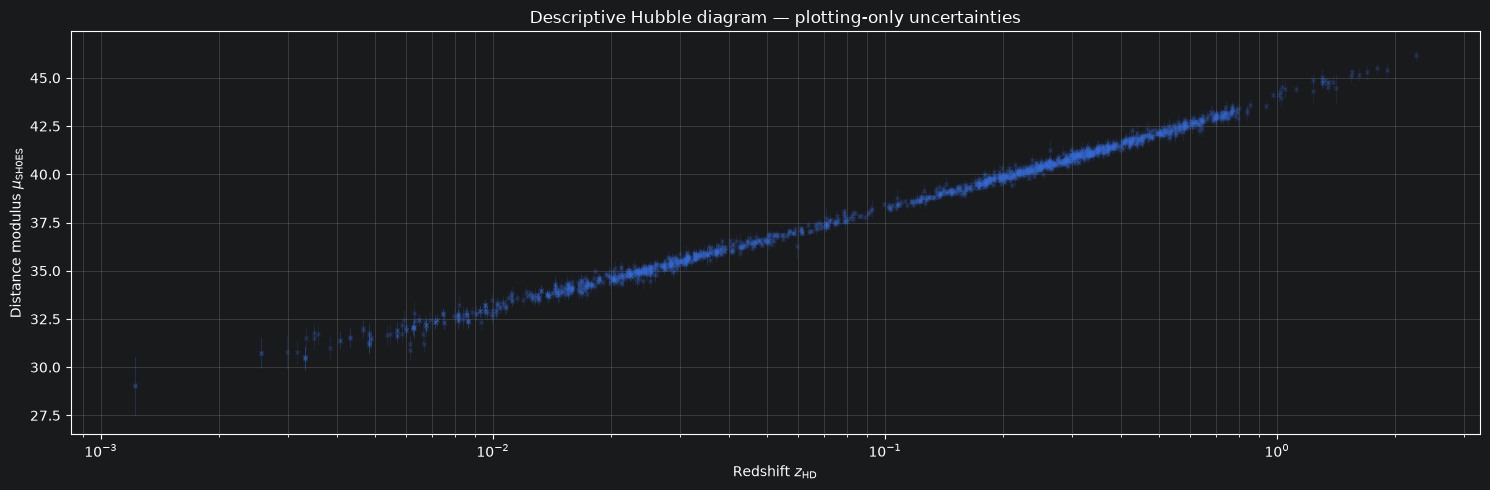

In [8]:
plt.figure(figsize=(15, 5))

plt.errorbar(
    df_A["zHD"],
    df_A["MU_SH0ES"],
    yerr=df_A["MU_SH0ES_ERR_DIAG"],
    fmt="x",
    markersize=3,
    alpha=0.25,
    elinewidth=0.4,
)

plt.xlabel("Redshift $z_{\\rm HD}$")
plt.ylabel("Distance modulus $\\mu_{\\rm SH0ES}$")
plt.title("Descriptive Hubble diagram — plotting-only uncertainties")

plt.xscale("log")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

We can also convert the provided distance modulus into an inferred distance in Mpc:

$$
d_{\rm Mpc} = 10^{(\mu - 25)/5}.
$$

This plot is useful for intuition, but the main supernova analysis is still more naturally done in magnitude space

Because the transformation from distance modulus to distance is nonlinear,
symmetric uncertainties in $\mu$ become asymmetric uncertainties in distance.
The conversion remains illustrative because the input uncertainties are
plotting-only quantities.

In [9]:
def distance_mpc_from_mu(mu):
    d_pc = 10**((mu+5)/5)
    d_Mpc = d_pc/(1e6)
    return d_Mpc

def sigma_distance_mpc_from_sigma_mu(d_Mpc, sigma_mu):
    return (np.log(10) / 5) * d_Mpc * sigma_mu

df_A["d_Mpc"] = distance_mpc_from_mu(df_A["MU_SH0ES"])
df_A["sigma_d_Mpc"] = sigma_distance_mpc_from_sigma_mu( df_A["d_Mpc"], df_A["MU_SH0ES_ERR_DIAG"])

The distance uncertainty is obtained by linear propagation,

$$
\sigma_d \simeq \frac{\ln 10}{5}\,d\,\sigma_\mu.
$$

This approximation is used only for an illustrative plot. The parameter
inference itself is performed in magnitude space.

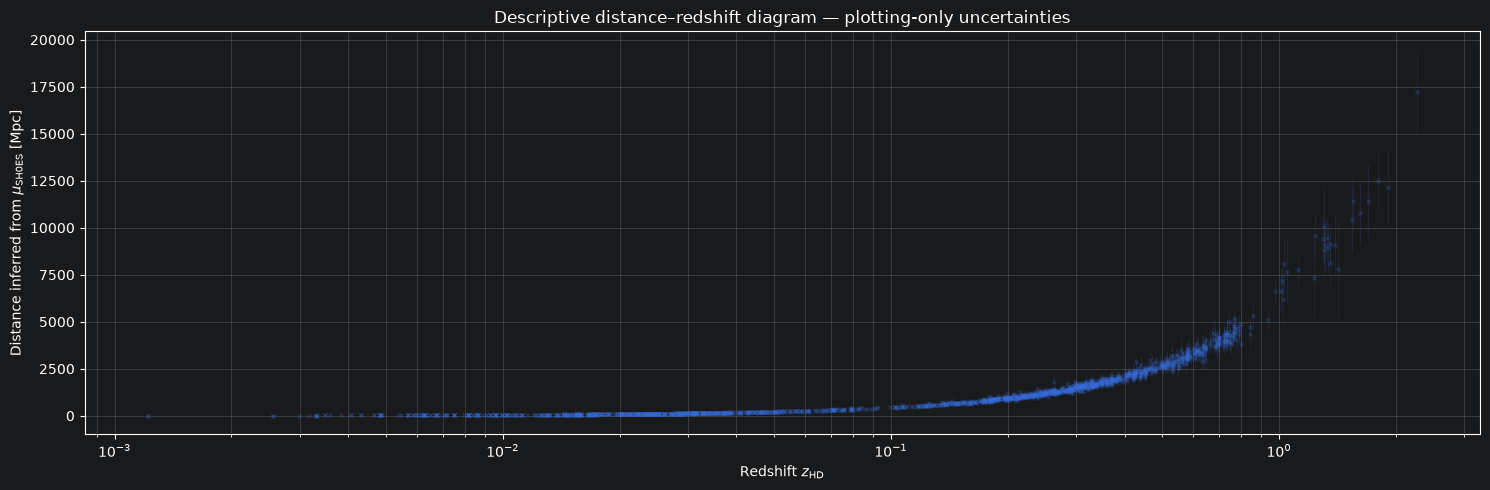

In [10]:
plt.figure(figsize=(15, 5))

plt.errorbar(
    df_A["zHD"],
    df_A["d_Mpc"],
    yerr=df_A["sigma_d_Mpc"],
    fmt="x",
    markersize=3,
    alpha=0.25,
    elinewidth=0.4,
)

plt.xlabel("Redshift $z_{\\rm HD}$")
plt.ylabel("Distance inferred from $\\mu_{\\rm SH0ES}$ [Mpc]")
plt.title("Descriptive distance–redshift diagram — plotting-only uncertainties")

plt.xscale("log")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

We now repeat the same descriptive plots for the SH0ES Hubble-flow subsample, selected with `USED_IN_SH0ES_HF == 1`.

In [11]:
mask = df_A['USED_IN_SH0ES_HF'] == 1

df_hf_mu = df_A[mask].copy()
print(df_hf_mu.shape)
print(df_hf_mu.head())

(277, 8)
             CID      zHD  MU_SH0ES  MU_SH0ES_ERR_DIAG  IS_CALIBRATOR  \
341       2009cz  0.02343   34.8582           0.260273              0   
342       2009cz  0.02343   34.8582           0.170636              0   
343  ASASSN-15nr  0.02344   34.8331           0.263771              0   
344       2004bk  0.02352   34.8391           0.215880              0   
346       2007qe  0.02357   35.0406           0.206572              0   

     USED_IN_SH0ES_HF       d_Mpc  sigma_d_Mpc  
341                 1   93.678516    11.228321  
342                 1   93.678516     7.361331  
343                 1   92.601922    11.248451  
344                 1   92.858144     9.231624  
346                 1  101.887287     9.692530  


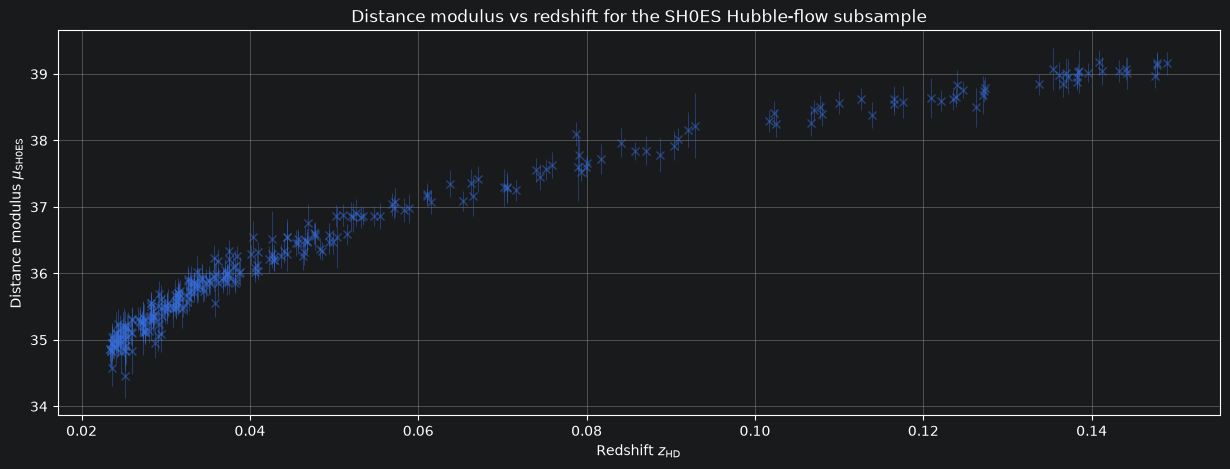

In [12]:
plt.figure(figsize=(15,5))
plt.errorbar( df_hf_mu["zHD"], df_hf_mu["MU_SH0ES"], yerr=df_hf_mu["MU_SH0ES_ERR_DIAG"], fmt="x", markersize=6, alpha=0.5, elinewidth=0.6)
plt.xlabel("Redshift $z_{\\rm HD}$")
plt.ylabel("Distance modulus $\\mu_{\\rm SH0ES}$")
plt.title("Distance modulus vs redshift for the SH0ES Hubble-flow subsample")
plt.grid(True)
plt.show()

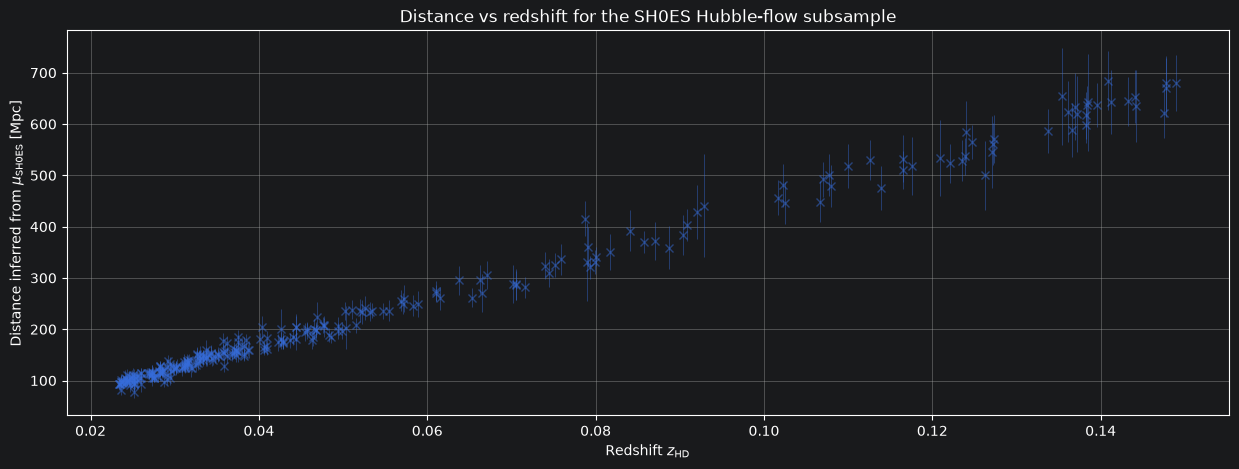

In [13]:
plt.figure(figsize=(15,5))
plt.errorbar( df_hf_mu["zHD"], df_hf_mu["d_Mpc"], yerr=df_hf_mu["sigma_d_Mpc"], fmt="x", markersize=6, alpha=0.5, elinewidth=0.6)
plt.xlabel("Redshift $z_{\\rm HD}$")
plt.ylabel("Distance inferred from $\\mu_{\\rm SH0ES}$ [Mpc]")
plt.title("Distance vs redshift for the SH0ES Hubble-flow subsample")
plt.grid(True)
plt.show()


## 4. Part B — Simplified distance-ladder fit

> **Pedagogical warning — not a cosmological inference.**
> The Pantheon+SH0ES release explicitly states that `m_b_corr_err_DIAG` and
> `MU_SH0ES_ERR_DIAG` are intended only for plotting and must not be used to fit
> cosmological parameters. This section nevertheless uses them deliberately to
> construct a transparent first approximation to the distance ladder.
>
> The posterior obtained below is therefore an instructional result. Notebook 6
> replaces this treatment with the full covariance matrix and a more accurate
> luminosity-distance relation.

In this part, we build a simplified version of the local distance ladder.

The logic is:

1. Use calibrator supernovae to estimate the absolute magnitude $M_{\rm SN}$.
2. Use Hubble-flow supernovae to estimate $H_0$.

For calibrator supernovae, the Cepheid distance modulus is known. Therefore we can estimate

$$
M_{{\rm SN},j}
=
m_{b,\rm corr,j}
-
\mu_{{\rm Cepheid},j}.
$$

For Hubble-flow supernovae, we model the corrected apparent magnitude as

$$
m_{b,\rm corr,i}^{\rm model}
=
M_{\rm SN}
+
5\log_{10}\left(\frac{cz_i}{H_0}\right)
+
25.
$$

This is still simplified, but it follows the same conceptual structure as the toy distance ladder from Notebook 4.

In [14]:
# Select calibrator supernovae with a positive Cepheid distance modulus

mask_calib = (df_B["IS_CALIBRATOR"] == 1) & (df_B["CEPH_DIST"] > 0)

df_b_calib = df_B[mask_calib].copy()

print(df_b_calib.shape)
print(df_b_calib.head())

(77, 8)
      CID      zHD  m_b_corr  m_b_corr_err_DIAG  m_b_corr_err_VPEC  CEPH_DIST  \
0  2011fe  0.00122   9.74571           1.516210             1.4960    29.1770   
1  2011fe  0.00122   9.80286           1.517230             1.4960    29.1770   
2  2012cg  0.00256  11.47030           0.781906             0.7134    30.8433   
3  2012cg  0.00256  11.49190           0.798612             0.7134    30.8433   
5   1981B  0.00317  11.54160           0.613941             0.5763    30.8338   

   IS_CALIBRATOR  USED_IN_SH0ES_HF  
0              1                 0  
1              1                 0  
2              1                 0  
3              1                 0  
5              1                 0  


For the nearest calibrators, the plotting uncertainty can be dominated by the
peculiar-velocity contribution. For example, for the first 2011fe measurement,
the total plotting uncertainty is approximately 1.516 mag, of which
approximately 1.496 mag comes from `m_b_corr_err_VPEC`.

However, the calibrator model uses the Cepheid distance modulus rather than the
supernova redshift. These plotting uncertainties are therefore not physically
appropriate weights for calibrating $M_{\rm SN}$. They are retained below
only to illustrate the mechanics of a weighted estimate.

In [15]:
df_b_calib["M_SN_individual"] = df_b_calib["m_b_corr"] - df_b_calib["CEPH_DIST"]
print(df_b_calib[["CID", "m_b_corr", "CEPH_DIST", "M_SN_individual"]].head())

      CID  m_b_corr  CEPH_DIST  M_SN_individual
0  2011fe   9.74571    29.1770        -19.43129
1  2011fe   9.80286    29.1770        -19.37414
2  2012cg  11.47030    30.8433        -19.37300
3  2012cg  11.49190    30.8433        -19.35140
5   1981B  11.54160    30.8338        -19.29220


In [16]:
# Sanity check: unweighted mean
M_simple = df_b_calib["M_SN_individual"].mean()
print(f"Simple mean M_SN = {M_simple:.4f} mag")

# Pedagogical weighted estimate using plotting-only errors
sigma_j_plot = df_b_calib["m_b_corr_err_DIAG"]
weights_plot = 1.0 / sigma_j_plot**2

M_weighted_ploterr = (
    np.sum(weights_plot * df_b_calib["M_SN_individual"])
    / np.sum(weights_plot)
)

sigma_M_weighted_ploterr = 1.0 / np.sqrt(np.sum(weights_plot))

print(
    "Weighted M_SN "
    f"= {M_weighted_ploterr:.4f} ± "
    f"{sigma_M_weighted_ploterr:.4f} mag"
)

Simple mean M_SN = -19.2715 mag
Weighted M_SN = -19.2517 ± 0.0400 mag


In [17]:
df_hf_real = df_B[df_B["USED_IN_SH0ES_HF"] == 1].copy()
print(df_hf_real.head())

             CID      zHD  m_b_corr  m_b_corr_err_DIAG  m_b_corr_err_VPEC  \
341       2009cz  0.02343   15.6052           0.258869             0.0797   
342       2009cz  0.02343   15.6052           0.168487             0.0797   
343  ASASSN-15nr  0.02344   15.5801           0.262385             0.0815   
344       2004bk  0.02352   15.5861           0.214185             0.0794   
346       2007qe  0.02357   15.7876           0.204800             0.0792   

     CEPH_DIST  IS_CALIBRATOR  USED_IN_SH0ES_HF  
341       -9.0              0                 1  
342       -9.0              0                 1  
343       -9.0              0                 1  
344       -9.0              0                 1  
346       -9.0              0                 1  


In [18]:
analysis_mask = mask_calib | (df_B["USED_IN_SH0ES_HF"] == 1)

n_analysis_rows = int(analysis_mask.sum())
n_unique_analysis_cids = df_B.loc[analysis_mask, "CID"].nunique()
n_repeated_analysis_rows = n_analysis_rows - n_unique_analysis_cids

print("Rows used in the simplified analysis:", n_analysis_rows)
print("Distinct supernova CIDs:", n_unique_analysis_cids)
print("Additional rows from repeated CIDs:", n_repeated_analysis_rows)

Rows used in the simplified analysis: 354
Distinct supernova CIDs: 281
Additional rows from repeated CIDs: 73


The dataset is organized by light-curve measurements rather than by unique
physical supernovae. Measurements sharing the same `CID` must not simply be
deleted, because each light curve can contain useful information.

In this simplified notebook, the diagonal likelihood implicitly treats these
rows as independent. Notebook 6 keeps all rows while accounting for their
correlations through the published covariance matrix.

### Chi-square for the real Hubble-flow fit

For the Hubble-flow supernovae, we model the corrected apparent magnitude using

$$
m_{\rm model}(z; H_0)
=
M_{\rm SN,calib}
+
5\log_{10}\left(\frac{cz}{H_0}\right)
+
25.
$$


To estimate $H_0$, we compare the observed corrected magnitudes $m_{b,\rm corr}$ to the model prediction. The residual for each supernova is

$$
r_i =
m_{b,\rm corr,i}
-
m_{\rm model}(z_i;H_0).
$$

Assuming Gaussian uncertainties on the corrected magnitudes, the chi-square is

$$
\chi^2(H_0)
=
\sum_i
\left(
\frac{
m_{b,\rm corr,i}
-
m_{\rm model}(z_i;H_0)
}{
\sigma_{m,i}
}
\right)^2.
$$

Here, $\sigma_{m,i}$ is taken from `m_b_corr_err_DIAG`. Treating these
quantities as independent Gaussian uncertainties is a deliberate pedagogical
assumption and is not the likelihood recommended by the data release.

The luminosity-distance model is also restricted to the first-order
approximation

$$
d_L \simeq \frac{cz}{H_0}.
$$

Consequently, minimizing this chi-square gives the best-fitting $H_0$ only
within this simplified model.

In [19]:
def m_model_from_H0(H0, z, M_SN):
  log = 5*np.log10(c_km_s*z/H0)
  return M_SN + log +25

def chi2_H0_real(H0, z, m_obs, sigma_m, M_SN):
    if H0 <= 0:
        return np.inf
    m_model = m_model_from_H0(H0,z,M_SN)
    residuals = m_obs - m_model
    return np.sum((residuals / sigma_m) ** 2)


The complete independent-Gaussian log-likelihood would also contain terms
involving $\log (\sigma_i)$ and $\log(2\pi)$. In this notebook, all
$\sigma_i$ are fixed and these terms do not depend on
$(H_0,M_{\rm SN})$. Omitting them therefore changes the absolute
normalization of the likelihood, but not the posterior shape or parameter
estimates.

This does not solve the more important limitation that the selected
$\sigma_i$ are plotting-only quantities.

In [20]:
initial_guess = np.array([70.0])

result = minimize(
    chi2_H0_real,
    initial_guess,
    args=(df_hf_real['zHD'], df_hf_real['m_b_corr'], df_hf_real['m_b_corr_err_DIAG'], M_weighted_ploterr),
)

assert result.success, result.message

H0_best_simple = result.x[0]

print("Pedagogical best-fit H0 "f"= {H0_best_simple:.3f} km/s/Mpc")


Pedagogical best-fit H0 = 70.325 km/s/Mpc


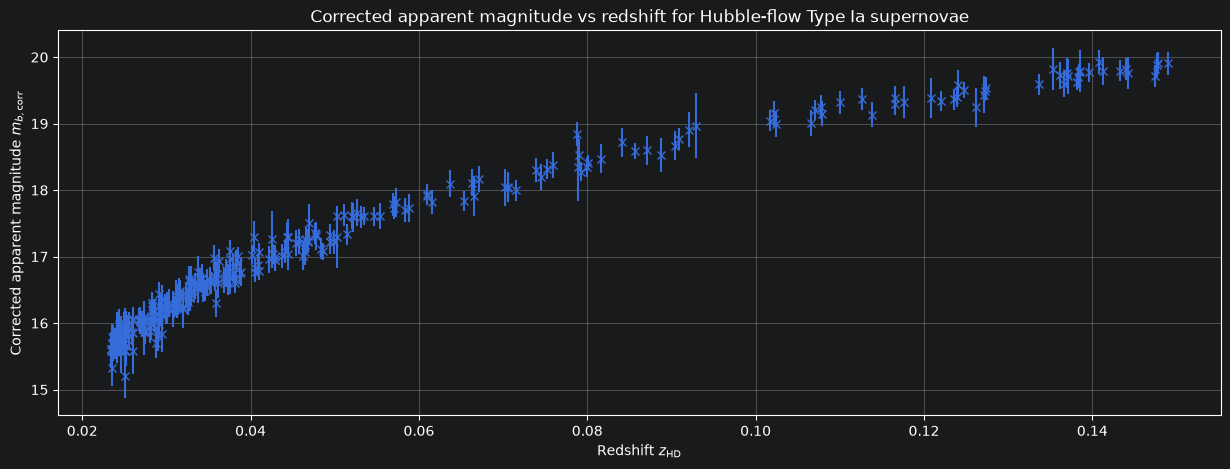

In [21]:
plt.figure(figsize=(15,5))
plt.errorbar(df_hf_real["zHD"], df_hf_real['m_b_corr'], yerr=df_hf_real['m_b_corr_err_DIAG'], fmt="x")
plt.xlabel("Redshift $z_{\\rm HD}$")
plt.ylabel("Corrected apparent magnitude $m_{b,\\rm corr}$")
plt.title("Corrected apparent magnitude vs redshift for Hubble-flow Type Ia supernovae")
plt.grid(True)
plt.show()

## 5. Bayesian two-parameter fit with `emcee`

The previous fit fixed the calibrated absolute magnitude $M_{\rm SN}$ and only optimized $H_0$.

We now use a more complete simplified model in which both parameters are inferred simultaneously:

$$
\theta = (H_0, M_{\rm SN}).
$$

The calibrator supernovae constrain $M_{\rm SN}$ through their Cepheid distance moduli:

$$
m_{b,\rm corr,j}^{\rm model}
=
M_{\rm SN}
+
\mu_{\rm Cepheid,j}.
$$

The Hubble-flow supernovae constrain the redshift-magnitude relation:

$$
m_{b,\rm corr,i}^{\rm model}
=
M_{\rm SN}
+
5\log_{10}\left(\frac{cz_i}{H_0}\right)
+
25.
$$

The total chi-square is

$$
\chi^2_{\rm total}
=
\chi^2_{\rm calib}
+
\chi^2_{\rm HF}.
$$

The log-likelihood is

$$
\log L
=
-\frac12 \chi^2_{\rm total}.
$$

This is still not a professional SH0ES analysis, because we ignore the full covariance matrix, Cepheid uncertainties, systematic errors, and a more accurate cosmological luminosity-distance relation. However, it is a realistic simplified distance-ladder model using real data.

In [22]:
df_calib_real = df_B[(df_B["IS_CALIBRATOR"] == 1) & (df_B["CEPH_DIST"] > 0)].copy()
df_hf_real = df_B[df_B["USED_IN_SH0ES_HF"] == 1].copy()

def chi2_calib(theta, m_calib, mu_cepheid, sigma_m_calib):
    H0, M_SN = theta
    residuals = m_calib - (M_SN + mu_cepheid)
    return np.sum((residuals / sigma_m_calib) ** 2)

def chi2_tot(theta, z, m_obs, sigma_m, m_calib, mu_cepheid, sigma_m_calib):
    H0, M_SN = theta
    chi2_c = chi2_calib(theta, m_calib, mu_cepheid, sigma_m_calib)
    chi2_hf = chi2_H0_real(H0, z, m_obs, sigma_m, M_SN)
    return chi2_c + chi2_hf

def log_L_tot(theta, z, m_obs, sigma_m, m_calib, mu_cepheid, sigma_m_calib):
    return -0.5 * chi2_tot(theta, z, m_obs, sigma_m, m_calib, mu_cepheid, sigma_m_calib)

def log_prior(theta):
    H0, M_SN = theta
    if 50.0 < H0 < 90.0 and -20.5 < M_SN < -18.0:
        return 0.0
    return -np.inf

def log_posterior(theta, z, m_obs, sigma_m, m_calib, mu_cepheid, sigma_m_calib):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_L_tot(theta, z, m_obs, sigma_m, m_calib, mu_cepheid, sigma_m_calib)

In [23]:
theta_start = np.array([H0_best_simple, M_weighted_ploterr])

print(log_posterior(theta_start, df_hf_real["zHD"], df_hf_real["m_b_corr"], df_hf_real["m_b_corr_err_DIAG"], df_calib_real["m_b_corr"], df_calib_real["CEPH_DIST"], df_calib_real["m_b_corr_err_DIAG"]))


-79.85638398884534


In [24]:
z_hf = df_hf_real["zHD"].to_numpy()
m_hf = df_hf_real["m_b_corr"].to_numpy()
sigma_hf = df_hf_real["m_b_corr_err_DIAG"].to_numpy()

m_calib = df_calib_real["m_b_corr"].to_numpy()
mu_cepheid = df_calib_real["CEPH_DIST"].to_numpy()
sigma_calib = df_calib_real["m_b_corr_err_DIAG"].to_numpy()

In [25]:
ndim = 2
nwalkers = 32
nsteps = 4000

theta_start = np.array([H0_best_simple, M_weighted_ploterr])

np.random.seed(42)  # internal emcee proposals
rng = np.random.default_rng(42)  # initial walker positions

p0 = theta_start + np.array([0.1, 0.01]) * rng.normal(size=(nwalkers, ndim))

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_posterior,
    args=(z_hf, m_hf, sigma_hf, m_calib, mu_cepheid, sigma_calib)
)

_ = sampler.run_mcmc(p0, nsteps, progress=True)

mean_acceptance = np.mean(sampler.acceptance_fraction)
print("Mean acceptance fraction:", mean_acceptance)

100%|██████████| 4000/4000 [00:03<00:00, 1011.84it/s]

Mean acceptance fraction: 0.716015625


The mean acceptance fraction is reported as a sampling diagnostic, but it is
not a convergence test. A high or moderate acceptance fraction does not prove
that the walkers have explored the stationary distribution.

We therefore inspect the traces and estimate the integrated autocorrelation
time and the effective sample size. The more complete covariance-aware
analysis and convergence diagnostics are deferred to Notebook 6.

(4000, 32, 2)


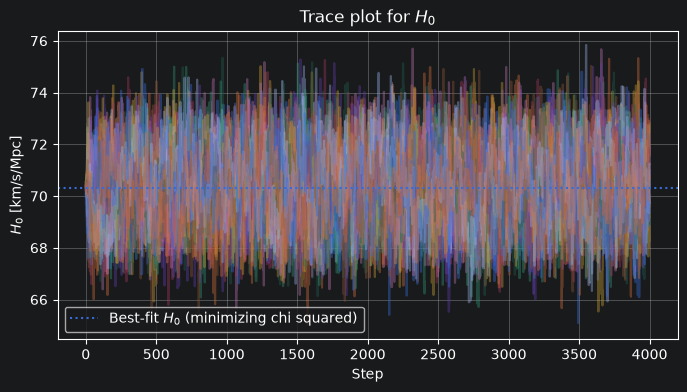

In [26]:
samples = sampler.get_chain()
print(samples.shape)

plt.figure(figsize=(8, 4))

for walker in range(nwalkers):
    plt.plot(samples[:, walker, 0], alpha=0.4)

plt.axhline(H0_best_simple, linestyle=":", label="Best-fit $H_0$ (minimizing chi squared)")

plt.xlabel("Step")
plt.ylabel("$H_0$ [km/s/Mpc]")
plt.title("Trace plot for $H_0$")
plt.grid(True)
plt.legend()
plt.show()

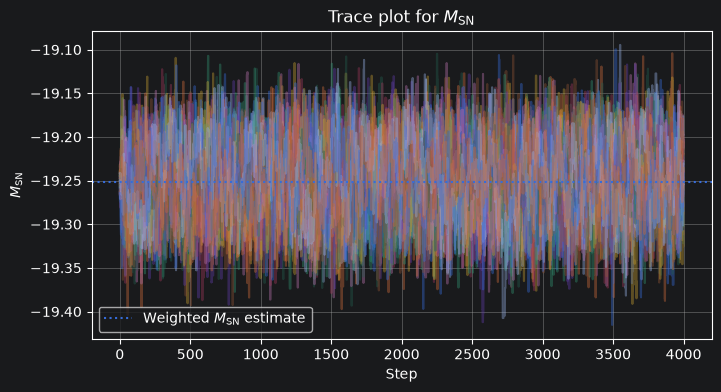

In [27]:
plt.figure(figsize=(8, 4))

for walker in range(nwalkers):
    plt.plot(samples[:, walker, 1], alpha=0.4)

plt.axhline(M_weighted_ploterr, linestyle=":", label="Weighted $M_{\\rm SN}$ estimate")

plt.xlabel("Step")
plt.ylabel("$M_{\\rm SN}$")
plt.title("Trace plot for $M_{\\rm SN}$")
plt.grid(True)
plt.legend()
plt.show()

In [28]:
burn_in = 500

try:
    tau = sampler.get_autocorr_time(discard=burn_in)
    autocorr_warning = False
except emcee.autocorr.AutocorrError as error:
    tau = error.tau
    autocorr_warning = True

ess = nwalkers * (nsteps - burn_in) / tau

for name, tau_value, ess_value in zip(
        ["H0", "M_SN"],
        tau,
        ess,
):
    print(f"{name}: tau = {tau_value:.1f} steps, "f" approximate ESS = {ess_value:.0f}")

if autocorr_warning:
    print("Warning: the chain may be too short for a stable autocorrelation-time estimate.")

H0: tau = 30.8 steps,  approximate ESS = 3638
M_SN: tau = 31.0 steps,  approximate ESS = 3607


In [29]:
flat_samples = sampler.get_chain(discard=burn_in, flat=True)
print(flat_samples.shape)

H0_samples = flat_samples[:, 0]
M_samples = flat_samples[:, 1]

H0_q16, H0_q50, H0_q84 = np.percentile(H0_samples, [16, 50, 84])
M_q16, M_q50, M_q84 = np.percentile(M_samples, [16, 50, 84])

print(f"H0 = {H0_q50:.2f} +{H0_q84 - H0_q50:.2f} -{H0_q50 - H0_q16:.2f} km/s/Mpc")
print(f"M_SN = {M_q50:.3f} +{M_q84 - M_q50:.3f} -{M_q50 - M_q16:.3f} mag")

(112000, 2)
H0 = 70.40 +1.34 -1.36 km/s/Mpc
M_SN = -19.250 +0.040 -0.041 mag


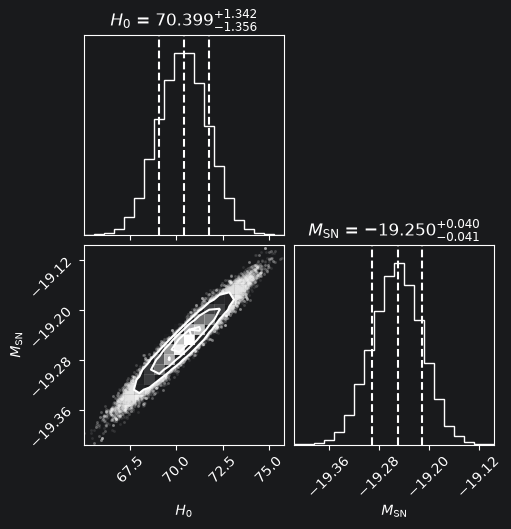

In [30]:
fig = corner.corner(
    flat_samples,
    labels=[r"$H_0$", r"$M_{\rm SN}$"],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
)

plt.show()

### Interpretation of the posterior

The MCMC samples the joint posterior distribution of the two parameters

$$
\theta = (H_0, M_{\rm SN}).
$$

The posterior median gives our Bayesian estimate of each parameter, while the 16th and 84th percentiles give an approximate 68% credible interval.

The corner plot shows that $H_0$ and $M_{\rm SN}$ are correlated. This is physically expected: changing the calibrated absolute magnitude changes the inferred supernova distances, and therefore changes the value of $H_0$ required to fit the Hubble-flow sample.

The numerical results are summarized below.

The posterior shows a positive correlation between $H_0$ and $M_{\rm SN}$:
a larger value of $H_0$ must be accompanied by a larger, less negative
absolute magnitude in order to preserve the predicted apparent magnitudes.

The width of this posterior is the uncertainty implied by the deliberately
simplified diagonal model. It is not a calibrated uncertainty on the physical
value of $H_0$.

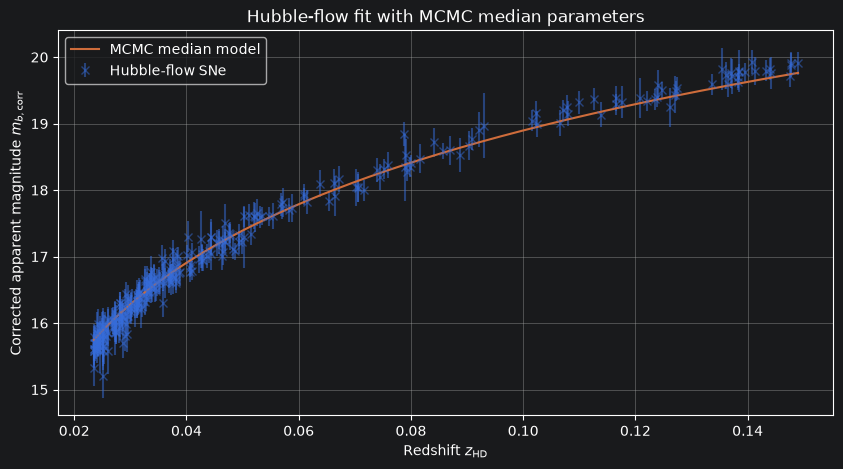

In [31]:
z_grid = np.linspace(df_hf_real["zHD"].min(), df_hf_real["zHD"].max(), 300)
m_grid = m_model_from_H0(H0_q50, z_grid, M_q50)

plt.figure(figsize=(10, 5))
plt.errorbar(
    df_hf_real["zHD"],
    df_hf_real["m_b_corr"],
    yerr=df_hf_real["m_b_corr_err_DIAG"],
    fmt="x",
    alpha=0.5,
    label="Hubble-flow SNe"
)

plt.plot(z_grid, m_grid, label="MCMC median model")

plt.xlabel("Redshift $z_{\\rm HD}$")
plt.ylabel("Corrected apparent magnitude $m_{b,\\rm corr}$")
plt.title("Hubble-flow fit with MCMC median parameters")
plt.grid(True)
plt.legend()
plt.show()

In [32]:
results = pd.DataFrame({
    "Quantity": ["H0", "M_SN"],
    "Median": [H0_q50, M_q50],
    "Minus": [H0_q50 - H0_q16, M_q50 - M_q16],
    "Plus": [H0_q84 - H0_q50, M_q84 - M_q50],
    "Unit": ["km/s/Mpc", "mag"]
})

results.round(3)

,Quantity,Median,Minus,Plus,Unit
0,H0,70.399,1.356,1.342,km/s/Mpc
1,M_SN,-19.250,0.041,0.040,mag


### Why does this notebook obtain $H_0 \simeq 70.35$ rather than 73.5?

The difference is not primarily caused by the covariance matrix.

Using the same 77 calibrator rows, 277 Hubble-flow rows, and plotting-only
uncertainties:

- the approximation $d_L=cz/H_0$ gives $H_0 \simeq 70.33$;
- a low-redshift cosmographic luminosity distance gives
  $H_0 \simeq 73.25$.

With the full published covariance and the cosmographic model, Notebook 6 gives
approximately $H_0 \simeq 73.53$.

The dominant shift in the central value therefore comes from the physical
distance model. The covariance changes the relative weights, correlations,
and uncertainty, but it is not by itself responsible for shifting the result
from 70 to 73.

### Comparison with the fixed-$M_{\rm SN}$ fit

The fixed-$M_{\rm SN}$ optimization and the joint posterior give compatible
central values within the same simplified model. This is an internal
implementation check, not an independent validation of the model.

The joint analysis is more informative because $M_{\rm SN}$ is allowed to
vary and its calibration uncertainty is propagated into $H_0$. This
advantage comes from fitting both parameters, not from MCMC alone: a
two-parameter frequentist fit could also estimate their joint uncertainty.

## 6. Final intuition plot: Hubble law

To visualize the result in the familiar Hubble-law form, we convert the corrected apparent magnitudes into distances using the MCMC median value of $M_{\rm SN}$.

For each Hubble-flow supernova,

$$
\mu_i = m_{b,\rm corr,i} - M_{\rm SN},
$$

and

$$
d_i = 10^{(\mu_i - 25)/5} \ {\rm Mpc}.
$$

We then compare the recession velocity

$$
v_i \approx cz_i
$$

to the Hubble-law prediction

$$
v = H_0 d.
$$

This plot is mainly for intuition. The actual fit was performed in magnitude space.

Because the distances are inferred using the fitted value of $M_{\rm SN}$, this plot is not an independent validation of the fit. It is mainly a visualization of the final result in the familiar Hubble-law form.

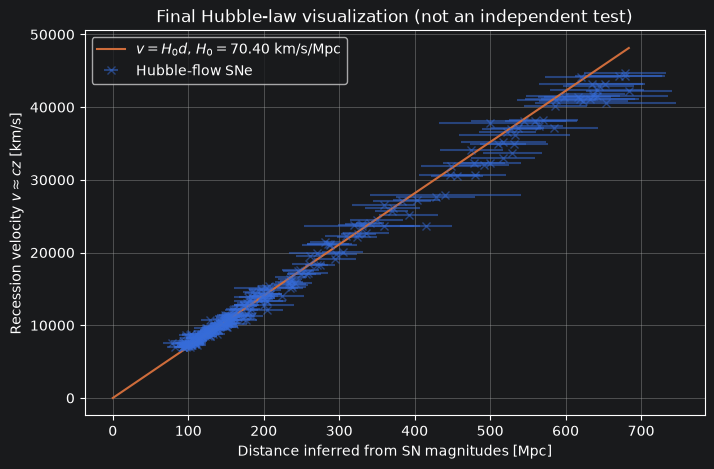

In [33]:
# Convert Hubble-flow magnitudes into distances using the MCMC median M_SN

mu_hf = df_hf_real["m_b_corr"] - M_q50
d_hf_Mpc = 10 ** ((mu_hf - 25) / 5)

v_hf = c_km_s * df_hf_real["zHD"]

# Approximate distance uncertainty from magnitude uncertainty
sigma_mu_hf = df_hf_real["m_b_corr_err_DIAG"]
sigma_d_hf_Mpc = (np.log(10) / 5) * d_hf_Mpc * sigma_mu_hf

# Hubble-law line using the MCMC median H0
d_grid = np.linspace(0, d_hf_Mpc.max(), 300)
v_grid = H0_q50 * d_grid

plt.figure(figsize=(8, 5))

plt.errorbar(
    d_hf_Mpc,
    v_hf,
    xerr=sigma_d_hf_Mpc,
    fmt="x",
    alpha=0.5,
    label="Hubble-flow SNe"
)

plt.plot(
    d_grid,
    v_grid,
    label=fr"$v = H_0 d$, $H_0 = {H0_q50:.2f}$ km/s/Mpc"
)

plt.xlabel("Distance inferred from SN magnitudes [Mpc]")
plt.ylabel("Recession velocity $v \\approx cz$ [km/s]")
plt.title("Final Hubble-law visualization (not an independent test)")
plt.grid(True)
plt.legend()
plt.show()

## 7. Limitations and role of this simplified analysis

This notebook uses real Pantheon+SH0ES data, but its parameter inference is a
deliberate pedagogical approximation rather than a cosmological measurement.

The main limitations are:

1. `m_b_corr_err_DIAG` and `MU_SH0ES_ERR_DIAG` are plotting-only uncertainty
   columns. The official release requires the full covariance matrix for
   parameter inference.

2. The diagonal likelihood treats all 354 selected rows as independent, even
   though they correspond to only 281 distinct supernova CIDs. Repeated
   light-curve measurements can be correlated.

3. The calibrator weights can contain large peculiar-velocity contributions,
   even though the calibrator model uses Cepheid distances and not supernova
   redshifts.

4. The luminosity distance is approximated by
   $d_L \simeq cz/H_0$. This approximation is useful for introducing the
   Hubble law, but it is not accurate enough for a percent-level analysis over
   the redshift range of the SH0ES Hubble-flow sample.

5. Cepheid-host uncertainties and correlations, systematic uncertainties, and
   correlations between different supernova measurements are not propagated
   correctly without the published covariance matrix.

6. The corrected magnitudes and Cepheid distance moduli are already processed
   products of the Pantheon+SH0ES analysis. This notebook does not reconstruct
   the complete distance ladder from the original Cepheid and light-curve data.

As a consequence, the uncertainty obtained here is **uncontrolled**: ignoring
the full covariance can either underestimate or overestimate an uncertainty,
depending on the covariance structure and the adopted weights. It is therefore
not correct to state simply that the uncertainty is “probably too optimistic.”

The value $H_0 \simeq 70.35\ {\rm km\,s^{-1}\,Mpc^{-1}}$ mainly reflects the
first-order approximation $d_L \simeq cz/H_0$. Replacing that approximation
with a low-redshift cosmographic distance shifts the result to approximately
$73.25\ {\rm km\,s^{-1}\,Mpc^{-1}}$, even before introducing the full
covariance.

The achievement of this notebook is therefore conceptual: it connects real
supernova data, Cepheid calibration, absolute magnitude, chi-square,
likelihood, and a joint posterior for

$$
\theta=(H_0,M_{\rm SN}).
$$

Notebook 6 is the central scientific analysis. It retains the selected
measurements, introduces a more accurate luminosity-distance model, and uses
the full covariance matrix to account for statistical and systematic
correlations.